**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load Dataset**

In [2]:
df = pd.read_csv("mental_health.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


**Data Cleaning**

In [3]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Age filter (remove unrealistic values)
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

df.shape

(1251, 27)

**Clean Gender Column**

In [4]:
def clean_gender(g):
    g = str(g).lower()
    if 'female' in g:
        return 'female'
    elif 'male' in g:
        return 'male'
    else:
        return 'other'

df['Gender'] = df['Gender'].apply(clean_gender)

**Handle Missing Values**

In [5]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()

np.int64(0)

**Encode Categorical Variables**

In [6]:
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

**Exploratory Data Analysis**

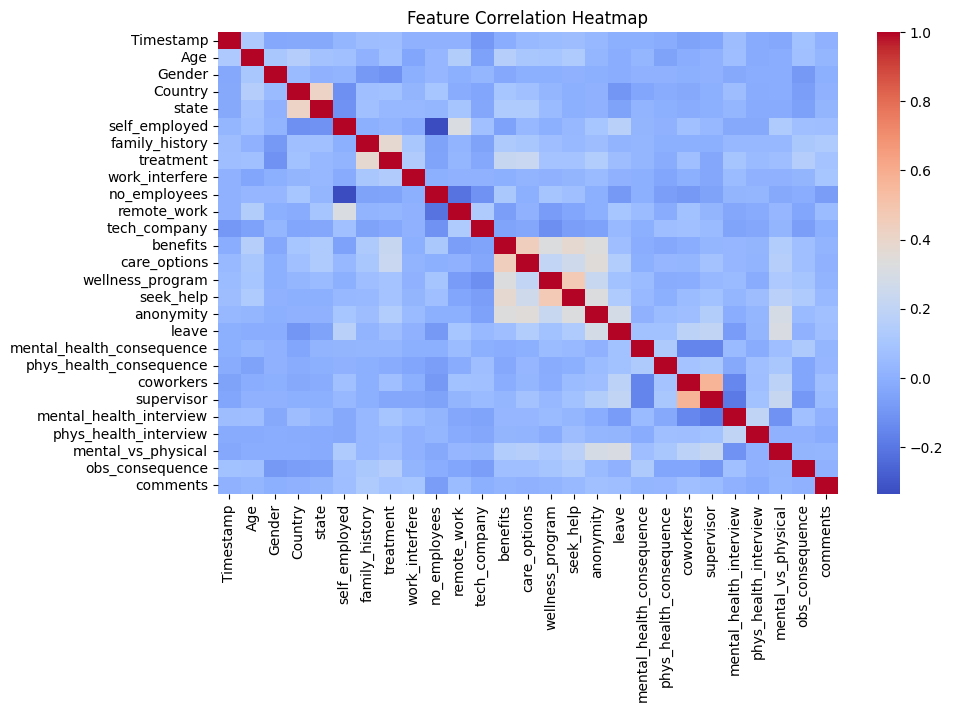

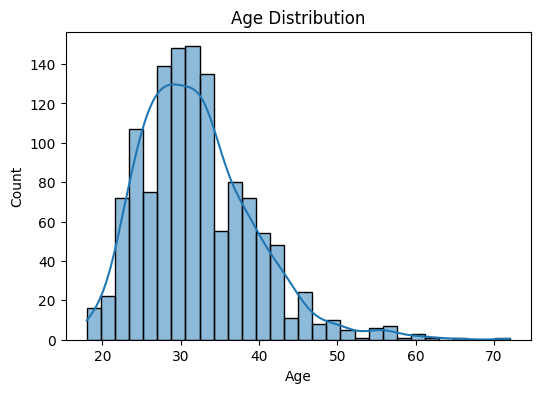

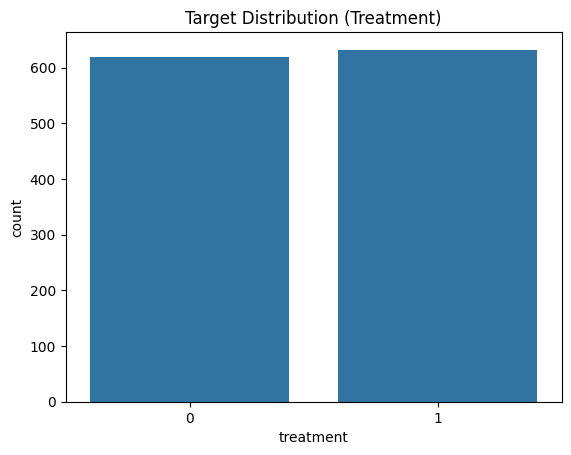

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

sns.countplot(x=df['treatment'])
plt.title("Target Distribution (Treatment)")
plt.show()

**Split Features & Target**

In [12]:
X = df.drop('treatment', axis=1)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model 1: Random Forest**

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7250996015936255
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       113
           1       0.76      0.72      0.74       138

    accuracy                           0.73       251
   macro avg       0.72      0.73      0.72       251
weighted avg       0.73      0.73      0.73       251



**Model 2: Logistic Regression**

In [14]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.6892430278884463
              precision    recall  f1-score   support

           0       0.64      0.73      0.68       113
           1       0.75      0.66      0.70       138

    accuracy                           0.69       251
   macro avg       0.69      0.69      0.69       251
weighted avg       0.70      0.69      0.69       251



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Confusion Matrix**

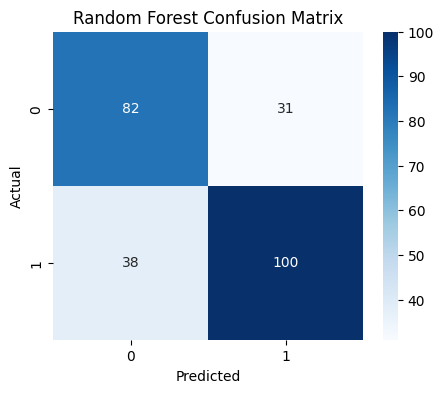

In [15]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Feature Importance**

In [16]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
7,work_interfere,0.105262
6,family_history,0.100451
0,Timestamp,0.096741
1,Age,0.084671
12,care_options,0.061670
11,benefits,0.044936
4,state,0.043369
3,Country,0.043020
8,no_employees,0.039080
16,leave,0.037202


**Visualization of Feature Importance**

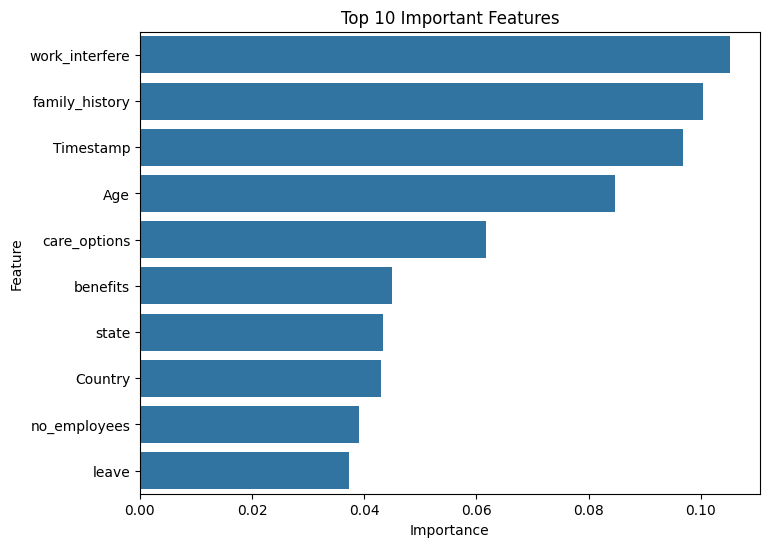

In [17]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

**BUSINESS INSIGHTS**

In [18]:
print("Key Insights from Data:\n")

print("- Work-related factors strongly influence mental health treatment seeking.")
print("- Workplace benefits and support systems play a major role.")
print("- Family history increases likelihood of seeking treatment.")
print("- Remote work and company environment also impact mental health decisions.")

Key Insights from Data:

- Work-related factors strongly influence mental health treatment seeking.
- Workplace benefits and support systems play a major role.
- Family history increases likelihood of seeking treatment.
- Remote work and company environment also impact mental health decisions.


**FINAL SUMMARY**

In [19]:
print("PROJECT SUMMARY")
print("----------------")
print("Built ML model to predict mental health treatment behavior")
print("Used Random Forest + Logistic Regression for comparison")
print("Performed data cleaning, encoding, and feature analysis")
print("Extracted key insights from workplace mental health data")
print("Achieved classification-based prediction system")

PROJECT SUMMARY
----------------
Built ML model to predict mental health treatment behavior
Used Random Forest + Logistic Regression for comparison
Performed data cleaning, encoding, and feature analysis
Extracted key insights from workplace mental health data
Achieved classification-based prediction system
